In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_direct_access(filename, ntot, dtype):
    data = np.fromfile(filename, dtype=dtype)
    n_iters = data.size // (3 * ntot)
    return data[:n_iters * 3 * ntot].reshape((n_iters, 3, ntot))

In [3]:
# --- Configuration ---
NTOT = 4108  # Set to your actual ntot
ITER_TO_PLOT = 1  # -1 means the last iteration saved
prefixes = ['cuda', 'fmm_l1', 'fmm_l2','fmm_l3']

# --- 1. Load All Data ---
h_data = {}
m_data = {}

for p in prefixes:
    h_data[p] = read_direct_access(f'{p}_debug_H_all.bin', NTOT, np.float32)
    m_data[p] = read_direct_access(f'{p}_debug_M_all.bin', NTOT, np.float64)


In [4]:
h_data['cuda'][0]

array([[-200937.78 , -117441.46 ,  -44525.914, ..., -240567.14 ,
        -437891.66 , -111833.555],
       [-200937.8  , -223835.61 , -237007.47 , ..., -437891.7  ,
        -240567.14 , -111833.56 ],
       [ 427065.66 ,  613513.44 ,  393326.47 , ...,  497956.4  ,
         497956.4  ,  132629.12 ]], shape=(3, 4108), dtype=float32)

In [5]:
h_data['fmm_l1'][0]

array([[-200937.77, -117441.43,  -44525.92, ..., -240567.14, -437891.7 ,
        -111833.54],
       [-200937.78, -223835.6 , -237007.47, ..., -437891.66, -240567.16,
        -111833.54],
       [ 427065.8 ,  613513.75,  393326.44, ...,  497956.4 ,  497956.38,
         132629.12]], shape=(3, 4108), dtype=float32)

In [8]:
h_data['fmm_l2'][0]

array([[-168230.8   ,  -10819.155 ,   21400.32  , ..., -279583.    ,
        -387618.47  , -321254.2   ],
       [-178237.45  , -170077.05  , -175172.03  , ..., -380088.22  ,
        -259388.42  , -306506.84  ],
       [  25968.26  ,  194800.16  ,  -93905.25  , ...,  -49333.117 ,
         -27765.137 ,   -6331.5815]], shape=(3, 4108), dtype=float32)

In [6]:
h_data['fmm_l2'][0]

array([[-168373.95  ,  -11008.924 ,   21195.713 , ..., -279583.97  ,
        -387622.16  , -321257.4   ],
       [-177618.47  , -169755.81  , -174933.8   , ..., -380106.3   ,
        -259404.61  , -306521.34  ],
       [  26646.434 ,  195581.75  ,  -93748.48  , ...,  -49308.402 ,
         -27743.91  ,   -6312.6836]], shape=(3, 4108), dtype=float32)

In [5]:
h_data['fmm_l2'][0]

array([[ -82284.75  , -119045.016 ,  -23000.254 , ...,  -64829.094 ,
         -69892.6   ,  -63229.316 ],
       [ -82470.5   , -101006.68  , -107999.945 , ...,  -69345.55  ,
         -64022.23  ,  -62654.324 ],
       [  -9964.463 ,   26874.44  ,  -29481.678 , ...,    -770.8058,
           -825.1424,     333.141 ]], shape=(3, 4108), dtype=float32)

In [11]:
h_data['fmm_l3'][0]

array([[-168375.72 ,  -11002.162,   21195.285, ..., -279583.22 ,
        -387621.44 , -321253.1  ],
       [-177614.44 , -169753.9  , -174925.08 , ..., -380108.9  ,
        -259407.73 , -306523.56 ],
       [  26658.355,  195580.53 ,  -93768.77 , ...,  -49308.906,
         -27744.773,   -6311.524]], shape=(3, 4108), dtype=float32)

In [5]:
h_data['fmm_l3'][0]

array([[-192364.72 , -107093.82 ,  -35463.516, ..., -165371.75 ,
        -356764.47 ,  -89062.695],
       [-192543.42 , -211929.31 , -222486.73 , ..., -357039.72 ,
        -165872.83 ,  -89155.695],
       [ 426578.22 ,  616234.4  ,  393422.8  , ...,  499427.12 ,
         499667.62 ,  132654.25 ]], shape=(3, 4108), dtype=float32)

In [16]:
h_data['fmm_l3'][0] + h_data['fmm_l2'][0]

array([[-200150.8 , -116515.75,  -43724.74, ..., -230201.16, -426657.06,
        -152289.12],
       [-200154.08, -222742.55, -235655.47, ..., -426385.2 , -229894.84,
        -151809.97],
       [ 427067.28,  613826.1 ,  393402.12, ...,  498656.38,  498842.78,
         132988.16]], shape=(3, 4108), dtype=float32)

In [17]:
h_data['fmm_l1'][0]

array([[-200937.77, -117441.43,  -44525.92, ..., -240567.14, -437891.7 ,
        -111833.54],
       [-200937.78, -223835.6 , -237007.47, ..., -437891.66, -240567.16,
        -111833.54],
       [ 427065.8 ,  613513.75,  393326.44, ...,  497956.4 ,  497956.38,
         132629.12]], shape=(3, 4108), dtype=float32)

-10347.609999999986

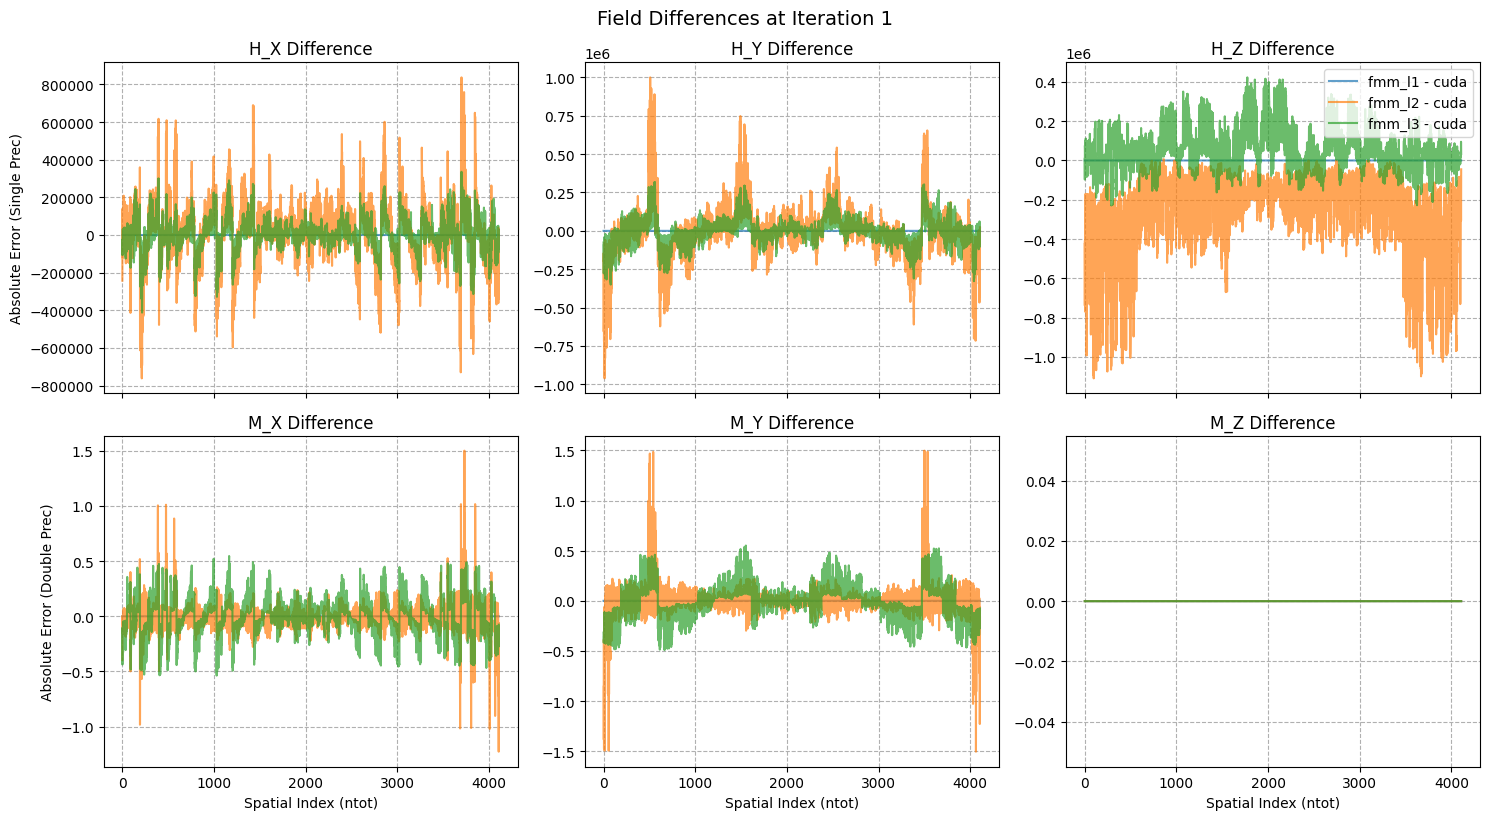

In [15]:
# --- 2. Create the 2x3 Comparison Plot ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
components = ['X', 'Y', 'Z']

for i, comp in enumerate(components):
    # --- Top Row: H-Field Differences ---
    ax_h = axes[0, i]
    # Calculate differences for H (Single Precision)
    diff_l1_h = h_data['fmm_l1'][ITER_TO_PLOT, i, :] - h_data['cuda'][ITER_TO_PLOT, i, :]
    diff_l2_h = h_data['fmm_l2'][ITER_TO_PLOT, i, :] - h_data['cuda'][ITER_TO_PLOT, i, :]
    diff_l3_h = h_data['fmm_l3'][ITER_TO_PLOT, i, :] - h_data['cuda'][ITER_TO_PLOT, i, :]
    
    ax_h.plot(diff_l1_h, label='fmm_l1 - cuda', alpha=0.7)
    ax_h.plot(diff_l2_h, label='fmm_l2 - cuda', alpha=0.7)
    ax_h.plot(diff_l3_h, label='fmm_l3 - cuda', alpha=0.7)
    ax_h.set_title(f'H_{comp} Difference')
    ax_h.grid(True, linestyle='--')
    if i == 0: ax_h.set_ylabel('Absolute Error (Single Prec)')

    # --- Bottom Row: M-Field Differences ---
    ax_m = axes[1, i]
    # Calculate differences for M (Double Precision)
    diff_l1_m = m_data['fmm_l1'][ITER_TO_PLOT, i, :] - m_data['cuda'][ITER_TO_PLOT, i, :]
    diff_l2_m = m_data['fmm_l2'][ITER_TO_PLOT, i, :] - m_data['cuda'][ITER_TO_PLOT, i, :]
    diff_l3_m = m_data['fmm_l3'][ITER_TO_PLOT, i, :] - m_data['cuda'][ITER_TO_PLOT, i, :]
    
    ax_m.plot(diff_l1_m, label='fmm_l1 - cuda', alpha=0.7)
    ax_m.plot(diff_l2_m, label='fmm_l2 - cuda', alpha=0.7)
    ax_m.plot(diff_l3_m, label='fmm_l3 - cuda', alpha=0.7)
    ax_m.set_title(f'M_{comp} Difference')
    ax_m.grid(True, linestyle='--')
    ax_m.set_xlabel('Spatial Index (ntot)')
    if i == 0: ax_m.set_ylabel('Absolute Error (Double Prec)')

# Add a single legend to the top right
axes[0, 2].legend(loc='upper right')

plt.tight_layout()
plt.suptitle(f'Field Differences at Iteration {ITER_TO_PLOT}', y=1.02, fontsize=14)
plt.show()

In [ ]:
# --- 3. Best Way to Compare (Numerical Summary) ---
print("--- Relative L2 Errors (Iteration %d) ---" % ITER_TO_PLOT)
for p in ['fmm_l2', 'fmm_l3']:
    # Compute Norm of difference / Norm of baseline
    h_err = np.linalg.norm(h_data[p][ITER_TO_PLOT] - h_data['cuda'][ITER_TO_PLOT]) / \
            np.linalg.norm(h_data['cuda'][ITER_TO_PLOT])
    
    m_err = np.linalg.norm(m_data[p][ITER_TO_PLOT] - m_data['cuda'][ITER_TO_PLOT]) / \
            np.linalg.norm(m_data['cuda'][ITER_TO_PLOT])
    
    print(f"{p:8} | H error: {h_err:.2e} | M error: {m_err:.2e}")